# Amazon 1P/3P Analysis - Mattress

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [3]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [4]:
import re
from sklearn.feature_extraction.text import CountVectorizer
#from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MultipleLocator, FuncFormatter
from wordcloud import WordCloud, STOPWORDS

In [5]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [9]:
sql = f"""
SELECT * FROM `wook.stckln_amz_mattress_ms_trend` 
"""

df = bqclient.query(sql).to_dataframe()

In [11]:
print(df)

        RetailerSku         category    subcategory profile  \
0        B071WXNW9C    Foam Mattress    Non-Cooling       8   
1        B071WXNW9C    Foam Mattress    Non-Cooling       8   
2        B071WXNW9C    Foam Mattress    Non-Cooling       8   
3        B0DJVRNGKC  Spring Mattress  Pocket Spring      10   
4        B07PJXHJRF    Foam Mattress    Cooling/Gel      10   
...             ...              ...            ...     ...   
1180468  B0B8QLTHT5  Spring Mattress  Pocket Spring      10   
1180469  B01ACKF01Q    Foam Mattress    Non-Cooling       6   
1180470  B09Z2F96RP  Spring Mattress  Pocket Spring      11   
1180471  B06XSGYGLV    Foam Mattress    Cooling/Gel       8   
1180472  B0DJVRNGKC  Spring Mattress  Pocket Spring      10   

                        size_raw     size bsr_ctgry_label bw_ff_type  \
0                     Short Full     Full  01. Mattresses       None   
1                     Short Full     Full  01. Mattresses       None   
2                     Short

In [15]:
df1 = df.copy()

In [17]:
# yr_month에서 year 추출
df1['year'] = df1['yr_month'].str[:2].astype(int) + 2000

# 확인
print(df1[['yr_month', 'year']].head())

  yr_month  year
0    19-09  2019
1    19-08  2019
2    19-02  2019
3    25-07  2025
4    20-04  2020


In [19]:
df1['yr_week'].min()

'Y19 W01'

In [21]:
df1.groupby('year')['RetailerSku'].nunique()

year
2019     7554
2020     8705
2021    11494
2022     8786
2023    10771
2024    17478
2025    15937
Name: RetailerSku, dtype: int64

In [27]:
# 1) yr_month >= '25-01' 조건 필터
df_filtered = df1[df1['yr_month'] >= '25-01'].copy()

# 2) 그룹바이: bw_ff_type
result = (
    df_filtered.groupby('bw_ff_type', dropna=False)
    .agg(
        unique_sku=('RetailerSku', 'nunique'),   # distinct 개수
        total_sales=('RetailSales', 'sum')       # 매출 합계
    )
    .reset_index()
)

print(result)

  bw_ff_type  unique_sku   total_sales
0         1p        3306  5.859558e+08
1         2p        1509  2.702161e+08
2         3p        3945  2.466052e+08
3        NaN        8324  3.465109e+08


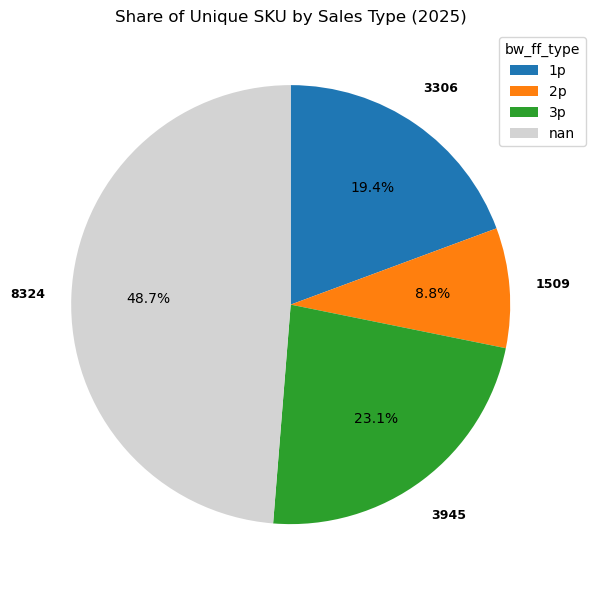

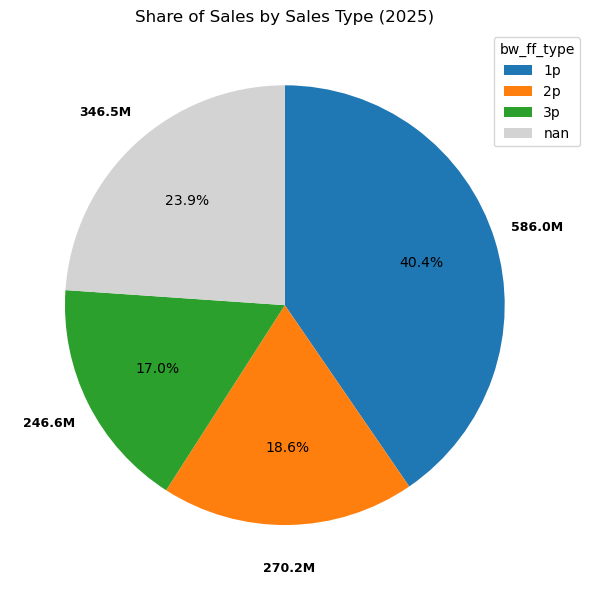

In [109]:


# --------- 1) Unique SKU 기준 파이차트 ---------
fig, ax = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax.pie(
    result['unique_sku'],
    labels=None,
    autopct="%.1f%%",         # % 표시
    startangle=90,
    counterclock=False,
    colors=pie_colors,
    pctdistance=0.65          # %를 안쪽에
)

# 유니크 SKU 개수 바깥쪽에 표시
for i, w in enumerate(wedges):
    ang = (w.theta2 - w.theta1)/2. + w.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    ax.text(
        x*1.2, y*1.2, f"{int(result['unique_sku'].iloc[i])}",  # 정수 개수
        ha='center', va='center', fontsize=9, weight='bold', color="black"
    )

ax.legend(result['bw_ff_type'], title="bw_ff_type", bbox_to_anchor=(1.05, 1))
ax.set_title("Share of Unique SKU by Sales Type (2025)")
plt.tight_layout()
plt.show()


# --------- 2) Sales 기준 파이차트 ---------
fig, ax = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax.pie(
    result['total_sales'],
    labels=None,
    autopct="%.1f%%",         # % 표시
    startangle=90,
    counterclock=False,
    colors=pie_colors,
    pctdistance=0.65          # %를 안쪽에
)

# 매출(Million) 바깥쪽에 표시
for i, w in enumerate(wedges):
    ang = (w.theta2 - w.theta1)/2. + w.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    val_million = result['total_sales'].iloc[i] / 1e6
    ax.text(
        x*1.2, y*1.2, f"{val_million:.1f}M",  # Million 단위
        ha='center', va='center', fontsize=9, weight='bold', color="black"
    )

ax.legend(result['bw_ff_type'], title="bw_ff_type", bbox_to_anchor=(1.05, 1))
ax.set_title("Share of Sales by Sales Type (2025)")
plt.tight_layout()
plt.show()

In [47]:
df_2025['RetailSales'].sum()

1449288086.9700005

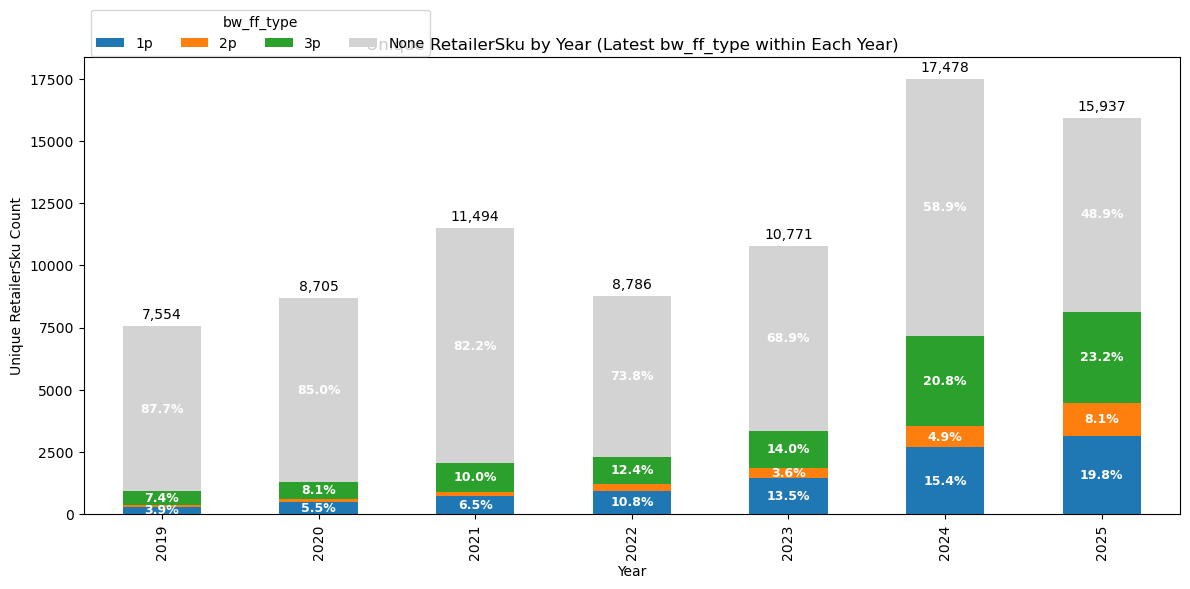

▶ 개수 (counts)
bw_ff_type_norm    1p    2p    3p   None
year                                    
2019              295    78   556   6625
2020              482   121   701   7401
2021              747   153  1149   9445
2022              950   257  1092   6487
2023             1453   388  1511   7419
2024             2693   848  3640  10297
2025             3161  1289  3692   7795

▶ 비중 (%)
bw_ff_type_norm    1p   2p    3p  None
year                                  
2019              3.9  1.0   7.4  87.7
2020              5.5  1.4   8.1  85.0
2021              6.5  1.3  10.0  82.2
2022             10.8  2.9  12.4  73.8
2023             13.5  3.6  14.0  68.9
2024             15.4  4.9  20.8  58.9
2025             19.8  8.1  23.2  48.9


In [37]:

# 2) bw_ff_type 정규화 (소문자/공백 정리). Null은 그대로 유지
def norm_type(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    # 흔한 표기 변형 정리
    if s in ['1p', '1', 'first-party', 'first party']:
        return '1p'
    if s in ['2p', '2', 'second-party', 'second party']:
        return '2p'
    if s in ['3p', '3', 'third-party', 'third party']:
        return '3p'
    return s  # 혹시 모르는 값은 원문 유지

df1['bw_ff_type_norm'] = df1['bw_ff_type'].apply(norm_type)

# 3) 연도별 & SKU별 최신 주차의 bw_ff_type 선택
#    (각 연도 내부에서 RetailerSku가 여러 행이면 가장 최신 WeekEnding 1건만 유지)
df_sorted = df1.sort_values(['year', 'RetailerSku', 'WeekEnding'])
latest_per_year_sku = (
    df_sorted
    .groupby(['year', 'RetailerSku'], dropna=False)
    .tail(1)  # 각 (year, SKU) 그룹에서 최신 주차 1행
)

# 4) 연도 × bw_ff_type별 unique SKU 개수 (Null 포함)
sku_counts = (
    latest_per_year_sku
    .groupby(['year', 'bw_ff_type_norm'], dropna=False)['RetailerSku']
    .nunique()
    .reset_index(name='sku_count')
)

# 5) 피벗(누적 막대용). 컬럼 순서: 1p, 2p, 3p, None
sku_pivot = (
    sku_counts
    .pivot(index='year', columns='bw_ff_type_norm', values='sku_count')
    .fillna(0)
)

# 컬럼 강제 정렬 및 누락 컬럼 보강
desired_cols = ['1p', '2p', '3p', np.nan]  # np.nan 컬럼이 None 레벨로 인식됨
# 현재 피벗에 없는 컬럼은 0으로 추가
for c in desired_cols:
    if c not in sku_pivot.columns:
        sku_pivot[c] = 0
sku_pivot = sku_pivot[desired_cols].astype(int).sort_index()

# 6) 비중(%) 계산
sku_ratio = sku_pivot.div(sku_pivot.sum(axis=1), axis=0) * 100

# 7) 색상 지정: None(Null)은 회색
colors = {
    '1p': '#1f77b4',   # 파랑
    '2p': '#ff7f0e',   # 주황
    '3p': '#2ca02c',   # 초록
    np.nan: 'lightgray'  # Null → 회색
}
bar_colors = [colors[col] for col in sku_pivot.columns]

# 8) 시각화 (누적 막대)
fig, ax = plt.subplots(figsize=(12, 6))
sku_pivot.plot(kind='bar', stacked=True, ax=ax, color=bar_colors)

plt.title("Unique RetailerSku by Year (Latest bw_ff_type within Each Year)")
plt.xlabel("Year")
plt.ylabel("Unique RetailerSku Count")
# 범례 라벨 정리 (np.nan → 'None')
handles, labels = ax.get_legend_handles_labels()
labels = ['1p' if l=='1p' else '2p' if l=='2p' else '3p' if l=='3p' else 'None' for l in labels]
ax.legend(handles, labels, title="bw_ff_type", ncol=4, loc='upper left', bbox_to_anchor=(0,1.12))

# 9) 각 세그먼트에 비중(%) 라벨 표시 (작은 조각은 생략)
min_ratio_to_show = 3.0  # 3% 미만 조각은 라벨 생략 (원하시면 조정)
for xi, yr in enumerate(sku_pivot.index):
    y_base = 0
    for col in sku_pivot.columns:
        count = sku_pivot.loc[yr, col]
        if count <= 0:
            continue
        ratio = sku_ratio.loc[yr, col]
        if ratio >= min_ratio_to_show:
            ax.text(
                xi, y_base + count/2,
                f"{ratio:.1f}%",
                ha='center', va='center', fontsize=9, color="white", weight="bold"
            )
        y_base += count

# 10) 연도별 총합 라벨(막대 위)
totals = sku_pivot.sum(axis=1)
for i, (yr, total) in enumerate(totals.items()):
    ax.text(i, total + max(totals)*0.01, f"{int(total):,}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 11) 표 확인: 개수 & 비중
print("▶ 개수 (counts)")
print(
    sku_pivot.rename(columns={np.nan: 'None'})
            .astype(int)
)

print("\n▶ 비중 (%)")
print(
    sku_ratio.rename(columns={np.nan: 'None'})
             .round(1)
)

In [37]:
# 1. 2025년 데이터만 필터링
df_2025 = df1[df1['year'] == 2025].copy()

# 2. bw_ff_type의 NaN → 'None' 변환
df_2025['bw_ff_type'] = df_2025['bw_ff_type'].fillna('None')

# 3. SKU별 최신 주차 데이터만 남기기
df_2025_sorted = df_2025.sort_values(['RetailerSku', 'WeekEnding'])
latest_2025 = df_2025_sorted.groupby('RetailerSku').tail(1)


In [43]:
print(latest_2025)

       RetailerSku       category  subcategory profile size_raw    size  \
550177  B000265S1I         OTHERS       OTHERS    None     None  OTHERS   
739188  B000WK740W         OTHERS       OTHERS    None     None  OTHERS   
951189  B000WZTVRG  Foam Mattress  Cooling/Gel    14.5     King    King   
458785  B0018Z0O2K         OTHERS       OTHERS    None     None  OTHERS   
848800  B001PQD10O  Foam Mattress  Cooling/Gel       8     Full    Full   
...            ...            ...          ...     ...      ...     ...   
200644  B0FNX4Y2JY         OTHERS       OTHERS    None     None  OTHERS   
641011  B0FP4JPGBB         OTHERS       OTHERS    None     None  OTHERS   
185217  B0FP9M25WG         OTHERS       OTHERS    None     None  OTHERS   
200200  B0FPCY4YJQ         OTHERS       OTHERS    None     None  OTHERS   
554452  B0FPLXPB56         OTHERS       OTHERS    None     None  OTHERS   

       bsr_ctgry_label bw_ff_type                Brand_raw  \
550177  01. Mattresses       None  GA

In [47]:
# 1. 2025년 데이터만 필터링
df_2025 = df1[df1['year'] == 2025].copy()

# 2. bw_ff_type의 NaN → 'None' 변환
df_2025['bw_ff_type'] = df_2025['bw_ff_type'].fillna('None')

# 3. SKU별 최신 주차 데이터만 남기기
#df_2025_sorted = df_2025.sort_values(['RetailerSku', 'WeekEnding'])
#latest_2025 = df_2025_sorted.groupby('RetailerSku').tail(1)

# 4. category × bw_ff_type별 unique SKU 개수 집계
sku_counts = (
    df_2025.groupby(['subcategory', 'bw_ff_type'])['RetailerSku']
               .nunique()
               .reset_index(name='sku_count')
)

print(sku_counts)

# 5. Pivot 변환 (개수 테이블)
sku_pivot = (
    sku_counts.pivot(index='subcategory', columns='bw_ff_type', values='sku_count')
              .fillna(0)
)

# 6. 컬럼 순서 고정
desired_cols = ['1p','2p','3p','None']
for c in desired_cols:
    if c not in sku_pivot.columns:
        sku_pivot[c] = 0
sku_pivot = sku_pivot[desired_cols].astype(int)

# 7. 비중 계산
sku_ratio = sku_pivot.div(sku_pivot.sum(axis=1), axis=0) * 100

# 8. 출력
print("▶ 2025 category별 SKU 개수")
print(sku_pivot)

print("\n▶ 2025 category별 SKU 비중 (%)")
print(sku_ratio.round(1))

      subcategory bw_ff_type  sku_count
0         Bonnell         1p        163
1         Bonnell         2p          4
2         Bonnell         3p         50
3         Bonnell       None        132
4     Cooling/Gel         1p       1247
5     Cooling/Gel         2p        231
6     Cooling/Gel         3p       1480
7     Cooling/Gel       None       1581
8     Non-Cooling         1p        642
9     Non-Cooling         2p        207
10    Non-Cooling         3p        836
11    Non-Cooling       None        756
12         OTHERS       None       2896
13  Pocket Spring         1p       1262
14  Pocket Spring         2p       1076
15  Pocket Spring         3p       1606
16  Pocket Spring       None       3083
▶ 2025 category별 SKU 개수
bw_ff_type       1p    2p    3p  None
subcategory                          
Bonnell         163     4    50   132
Cooling/Gel    1247   231  1480  1581
Non-Cooling     642   207   836   756
OTHERS            0     0     0  2896
Pocket Spring  1262  1076  1

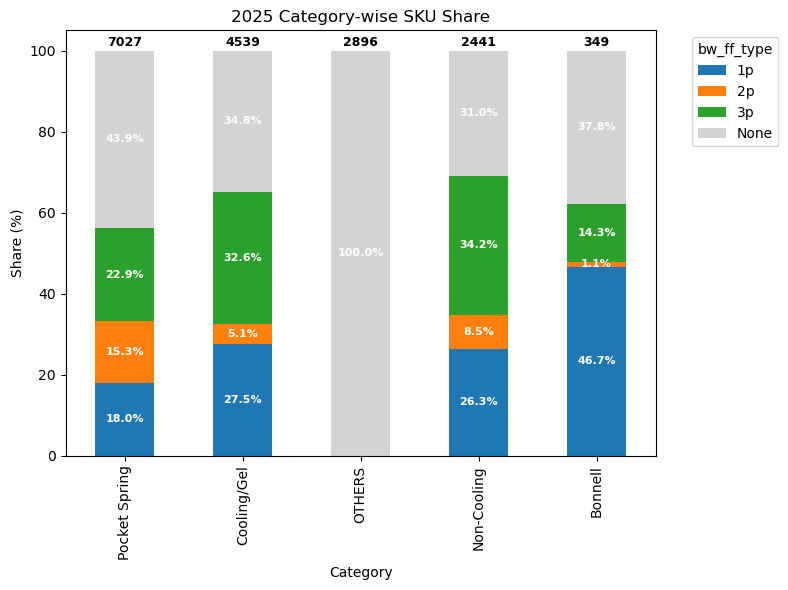

In [77]:
# ---------------------------------
# 1) 카테고리별 총 SKU 개수 계산 (sku_pivot 활용)
# ---------------------------------
sku_total = sku_pivot.sum(axis=1)

# ---------------------------------
# 2) SKU 개수 많은 순으로 정렬
# ---------------------------------
sku_ratio_sorted = sku_ratio.loc[sku_total.sort_values(ascending=False).index]
sku_total_sorted = sku_total.loc[sku_ratio_sorted.index]

# ---------------------------------
# 3) stacked bar chart (100%)
# ---------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

sku_ratio_sorted.plot(
    kind='bar',
    stacked=True,
    color=[colors[c] for c in sku_ratio_sorted.columns],
    ax=ax
)

# ---------------------------------
# 4) 퍼센트 값 라벨 표시
# ---------------------------------
for idx, row in sku_ratio_sorted.iterrows():
    cumulative = 0
    for col in sku_ratio_sorted.columns:
        val = row[col]
        if val > 0:
            ax.text(
                x=list(sku_ratio_sorted.index).index(idx),
                y=cumulative + val/2,
                s=f"{val:.1f}%",
                ha='center', va='center', fontsize=8, color="white", weight="bold"
            )
        cumulative += val

# ---------------------------------
# 5) 전체 유니크 SKU 개수 막대 상단에 표시
# ---------------------------------
for i, (cat, total) in enumerate(sku_total_sorted.items()):
    ax.text(
        x=i,
        y=100.5,  # stacked bar가 100%이므로 막대 상단 살짝 위
        s=f"{int(total)}",   # SKU 총 개수
        ha='center', va='bottom', fontsize=9, color="black", weight="bold"
    )

# ---------------------------------
# 6) 그래프 설정
# ---------------------------------
ax.set_ylabel("Share (%)")
ax.set_xlabel("Category")
ax.set_title("2025 Category-wise SKU Share")
ax.legend(title="bw_ff_type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [61]:
# 7) subcategory × 최신 bw_ff_type별 매출 합계
sales_by_type = (
    df_2025.groupby(['subcategory', 'bw_ff_type'], dropna=False)['RetailSales']
           .sum()
           .reset_index(name='sales')
)

# 8) Pivot (매출 합계 테이블)
sales_pivot = (
    sales_by_type.pivot(index='subcategory', columns='bw_ff_type', values='sales')
                 .fillna(0.0)
)

# 9) 컬럼 순서 고정
desired_cols = ['1p', '2p', '3p', 'None']
for c in desired_cols:
    if c not in sales_pivot.columns:
        sales_pivot[c] = 0.0
sales_pivot = sales_pivot[desired_cols]

# 10) 비중(%) 계산: 각 subcategory 행 합계 대비 100×
row_sums = sales_pivot.sum(axis=1).replace(0, np.nan)  # 0 나눗셈 방지
sales_ratio = sales_pivot.div(row_sums, axis=0) * 100
sales_ratio = sales_ratio.fillna(0.0)

# 11) 출력
print("▶ 2025 category별 매출 합계")
print(sales_pivot.round(2))

print("\n▶ 2025 category별 매출 비중 (%)")
print(sales_ratio.round(1))

▶ 2025 category별 매출 합계
bw_ff_type               1p            2p            3p          None
subcategory                                                          
Bonnell        3.083148e+07  3.757610e+05  1.876433e+06  3.873809e+06
Cooling/Gel    3.020956e+08  1.498607e+07  1.128769e+08  4.095193e+07
Non-Cooling    1.685784e+08  1.055260e+07  5.157301e+07  1.951390e+07
OTHERS         0.000000e+00  0.000000e+00  0.000000e+00  6.864171e+07
Pocket Spring  8.445031e+07  2.443017e+08  8.027884e+07  2.135296e+08

▶ 2025 category별 매출 비중 (%)
bw_ff_type       1p    2p    3p   None
subcategory                           
Bonnell        83.4   1.0   5.1   10.5
Cooling/Gel    64.2   3.2  24.0    8.7
Non-Cooling    67.4   4.2  20.6    7.8
OTHERS          0.0   0.0   0.0  100.0
Pocket Spring  13.6  39.2  12.9   34.3


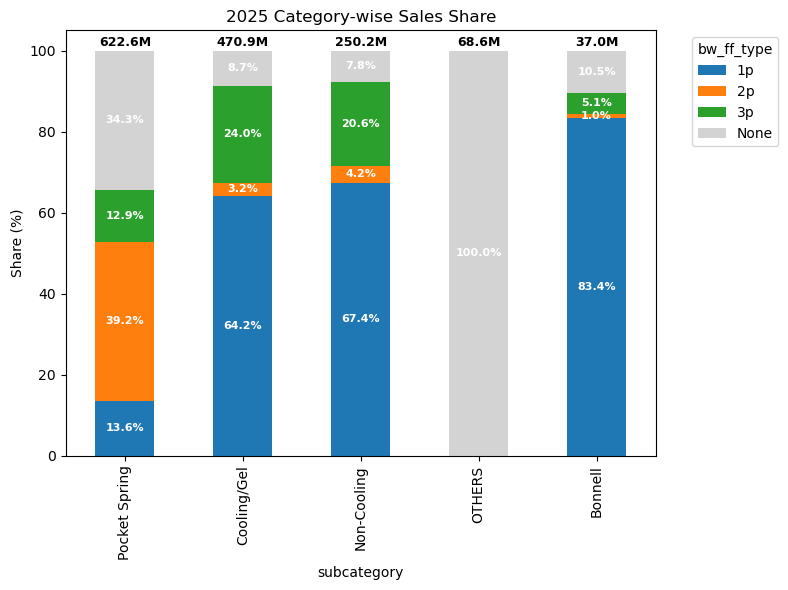

In [75]:

# ---------------------------------
# 1) 카테고리별 총 매출 (sales_pivot 활용)
# ---------------------------------
sales_total = sales_pivot.sum(axis=1)   # 매출 합계
sales_total_million = sales_total / 1e6 # Million 단위

# ---------------------------------
# 2) 매출 큰 순으로 정렬
# ---------------------------------
sales_ratio_sorted = sales_ratio.loc[sales_total.sort_values(ascending=False).index]
sales_total_sorted = sales_total_million.loc[sales_ratio_sorted.index]

# ---------------------------------
# 3) stacked bar (100%)
# ---------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

sales_ratio_sorted.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color={'1p':'#1f77b4', '2p':'#ff7f0e', '3p':'#2ca02c', 'None':'lightgray'}
)

# ---------------------------------
# 4) 퍼센트 표시
# ---------------------------------
for idx, row in sales_ratio_sorted.iterrows():
    cumulative = 0
    for col in sales_ratio_sorted.columns:
        val = row[col]
        if val > 0:
            ax.text(
                x=list(sales_ratio_sorted.index).index(idx),
                y=cumulative + val/2,
                s=f"{val:.1f}%",
                ha='center', va='center', fontsize=8, color="white", weight="bold"
            )
        cumulative += val

# ---------------------------------
# 5) 막대 상단에 총 매출(Million 단위) 표시
# ---------------------------------
for i, (cat, total) in enumerate(sales_total_sorted.items()):
    ax.text(
        x=i,
        y=100.5,  # stacked bar가 100%이므로 막대 상단 위
        s=f"{total:.1f}M",  # 소수점 첫째 자리까지 Million 단위
        ha='center', va='bottom', fontsize=9, color="black", weight="bold"
    )

# ---------------------------------
# 6) 그래프 설정
# ---------------------------------
ax.set_ylabel("Share (%)")
ax.set_title("2025 Category-wise Sales Share")
ax.legend(title="bw_ff_type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [101]:
# Pocket Spring 분석 
# ---------- 1. Pocket Spring + 2025 ----------
df_2025 = df1[df1['year'] == 2025].copy()
#df_2025['bw_ff_type'] = df_2025['bw_ff_type'].fillna('None')
#df_2025['RetailSales'] = pd.to_numeric(df_2025['RetailSales'], errors='coerce').fillna(0.0)

df_ps = df_2025[df_2025['subcategory'] == 'Pocket Spring'].copy()

# ---------- 2. SKU별 최신 bw_ff_type ----------
#df_ps_sorted = df_ps.sort_values(['RetailerSku', 'WeekEnding'])
#latest_ps = df_ps_sorted.groupby('RetailerSku').tail(1).copy()
df_ps['bw_ff_type'] = df_ps['bw_ff_type'].fillna('None')

# ---------- 3. Top 10 브랜드 (매출 기준) ----------
brand_sales = (
    df_ps.groupby('Brand_raw')
         .agg( RetailSales = ('RetailSales', 'sum'),
               unique_sku = ('RetailerSku', 'nunique')
         )
         .reset_index()
         .sort_values('RetailSales', ascending=False)
         .head(10)
)
top10_brands = brand_sales['Brand_raw'].tolist()

print("▶ Top 10 브랜드 (2025년 Pocket Spring 매출 기준)")
print(brand_sales)

# ---------- 4. (A) 개수 기반 비중 ----------
# 최신 SKU 기준으로만
sku_counts = (
    df_ps[df_ps['Brand_raw'].isin(top10_brands)]
    .groupby(['Brand_raw', 'bw_ff_type'])['RetailerSku']
    .nunique()
    .reset_index(name='sku_count')
)

sku_pivot = (
    sku_counts.pivot(index='Brand_raw', columns='bw_ff_type', values='sku_count')
    .fillna(0)
)

# 컬럼 순서 맞추기
desired_cols = ['1p', '2p', '3p', 'None']
for c in desired_cols:
    if c not in sku_pivot.columns:
        sku_pivot[c] = 0
sku_pivot = sku_pivot[desired_cols].astype(int)

sku_ratio = sku_pivot.div(sku_pivot.sum(axis=1), axis=0) * 100

# ---------- 5. (B) 매출 기반 비중 ----------
# 최신 bw_ff_type 매핑 후 매출 합계
#latest_map = latest_ps[['RetailerSku', 'bw_ff_type']].rename(
#    columns={'bw_ff_type': 'bw_ff_type_latest'}
#)
#df_ps = df_ps.merge(latest_map, on='RetailerSku', how='left')
#df_ps['bw_ff_type_latest'] = df_ps['bw_ff_type_latest'].fillna('None')

sales_by_brand = (
    df_ps[df_ps['Brand_raw'].isin(top10_brands)]
    .groupby(['Brand_raw', 'bw_ff_type'])['RetailSales']
    .sum()
    .reset_index(name='sales')
)

sales_pivot = (
    sales_by_brand.pivot(index='Brand_raw', columns='bw_ff_type', values='sales')
    .fillna(0.0)
)

for c in desired_cols:
    if c not in sales_pivot.columns:
        sales_pivot[c] = 0.0
sales_pivot = sales_pivot[desired_cols]

sales_ratio = sales_pivot.div(sales_pivot.sum(axis=1), axis=0) * 100

# ---------- 7. Top 10 Brand 순으로 정렬해 출력 ----------
ordered_brands = brand_sales['Brand_raw'].tolist()  # 이미 매출 내림차순 Top10

# (A) 개수 기반 비중 - 정렬/채움/반올림
sku_ratio_sorted = (
    sku_ratio
    .reindex(ordered_brands)   # Top10 브랜드 순서로 재배치
    .fillna(0)                 # 혹시 없는 값 0으로
    .round(1)
)

# (B) 매출 기반 비중 - 정렬/채움/반올림
sales_ratio_sorted = (
    sales_ratio
    .reindex(ordered_brands)   # Top10 브랜드 순서로 재배치
    .fillna(0)
    .round(1)
)

print("\n▶ Top 10 브랜드 - 개수 기반 비중 (Top10 Brand 순)")
print(sku_ratio_sorted)

print("\n▶ Top 10 브랜드 - 매출 기반 비중 (Top10 Brand 순)")
print(sales_ratio_sorted)

▶ Top 10 브랜드 (2025년 Pocket Spring 매출 기준)
                      Brand_raw  RetailSales  unique_sku
27                     BEDSTORY  20555913.64         198
318                       ZINUS  17341788.42          86
180                     MOLBIUS  17308205.80          11
93                 FP FLEXPEDIC  16245537.18         157
298                   VESGANTTI  16171891.36         141
247  SIGNATURE DESIGN BY ASHLEY  15797462.31          84
197                     NOVILLA  15631306.76         182
51                      COOLVIE  14526546.69          62
133                     KOANTTI  14017660.16          10
135                   KOULABR Z  11583254.12          17

▶ Top 10 브랜드 - 개수 기반 비중 (Top10 Brand 순)
bw_ff_type                    1p    2p    3p  None
Brand_raw                                         
BEDSTORY                     3.4   0.0  26.0  70.6
ZINUS                       52.2   1.1   5.6  41.1
MOLBIUS                      0.0  50.0   0.0  50.0
FP FLEXPEDIC                 0.6   0

In [83]:

# ---------- 1.  2025 ----------
df_2025 = df1[df1['year'] == 2025].copy()
df_2025['bw_ff_type'] = df_2025['bw_ff_type'].fillna('None')
#df_2025['RetailSales'] = pd.to_numeric(df_2025['RetailSales'], errors='coerce').fillna(0.0)

#df_ps = df_2025[df_2025['subcategory'] == 'Pocket Spring'].copy()

# ---------- 2. SKU별 최신 bw_ff_type ----------
#df_2025_sorted = df_2025.sort_values(['RetailerSku', 'WeekEnding'])
#latest_2025 = df_2025_sorted.groupby('RetailerSku').tail(1).copy()
#latest_2025['bw_ff_type'] = latest_2025['bw_ff_type'].fillna('None')

# ---------- 3. Top 10 브랜드 (매출 기준) ----------
brand_sales = (
    df_2025.groupby('Brand_raw')
         .agg( RetailSales = ('RetailSales', 'sum'),
               unique_sku = ('RetailerSku', 'nunique')
         )
         .reset_index()
         .sort_values('RetailSales', ascending=False)
         .head(10)
)
top10_brands = brand_sales['Brand_raw'].tolist()

print("▶ Top 10 브랜드 (2025년 매출 기준)")
print(brand_sales)

# ---------- 4. (A) 개수 기반 비중 ----------
# 최신 SKU 기준으로만
sku_counts = (
    df_2025[df_2025['Brand_raw'].isin(top10_brands)]
    .groupby(['Brand_raw', 'bw_ff_type'])['RetailerSku']
    .nunique()
    .reset_index(name='sku_count')
)

sku_pivot = (
    sku_counts.pivot(index='Brand_raw', columns='bw_ff_type', values='sku_count')
    .fillna(0)
)

# 컬럼 순서 맞추기
desired_cols = ['1p', '2p', '3p', 'None']
for c in desired_cols:
    if c not in sku_pivot.columns:
        sku_pivot[c] = 0
sku_pivot = sku_pivot[desired_cols].astype(int)

sku_ratio = sku_pivot.div(sku_pivot.sum(axis=1), axis=0) * 100

# ---------- 5. (B) 매출 기반 비중 ----------
sales_by_brand = (
    df_2025[df_2025['Brand_raw'].isin(top10_brands)]
    .groupby(['Brand_raw', 'bw_ff_type'])['RetailSales']
    .sum()
    .reset_index(name='sales')
)

sales_pivot = (
    sales_by_brand.pivot(index='Brand_raw', columns='bw_ff_type', values='sales')
    .fillna(0.0)
)

for c in desired_cols:
    if c not in sales_pivot.columns:
        sales_pivot[c] = 0.0
sales_pivot = sales_pivot[desired_cols]

sales_ratio = sales_pivot.div(sales_pivot.sum(axis=1), axis=0) * 100

# ---------- 6. 결과 출력 ----------
print("\n▶ Top 10 브랜드 - 개수 기반 비중")
print(sku_ratio.round(1))

print("\n▶ Top 10 브랜드 - 매출 기반 비중")
print(sales_ratio.round(1))

▶ Top 10 브랜드 (2025년 매출 기준)
                      Brand_raw   RetailSales  unique_sku
731                       ZINUS  2.049243e+08         333
463                     NOVILLA  9.482808e+07         580
202                         FDW  5.339066e+07         104
449                      NECTAR  5.294678e+07          92
424                       MLILY  4.965466e+07         214
50                     BEDSTORY  2.962916e+07         290
225                      GAESTE  2.632508e+07          47
574  SIGNATURE DESIGN BY ASHLEY  2.497327e+07         165
117                    COOL GEL  2.366301e+07          25
177                     EGOHOME  2.270285e+07          58

▶ Top 10 브랜드 - 개수 기반 비중
bw_ff_type                    1p   2p    3p  None
Brand_raw                                        
BEDSTORY                     2.4  0.0  18.2  79.4
COOL GEL                    19.2  0.0  65.4  15.4
EGOHOME                     28.1  0.0  51.6  20.3
FDW                         79.8  0.0   0.0  20.2
GAESTE    

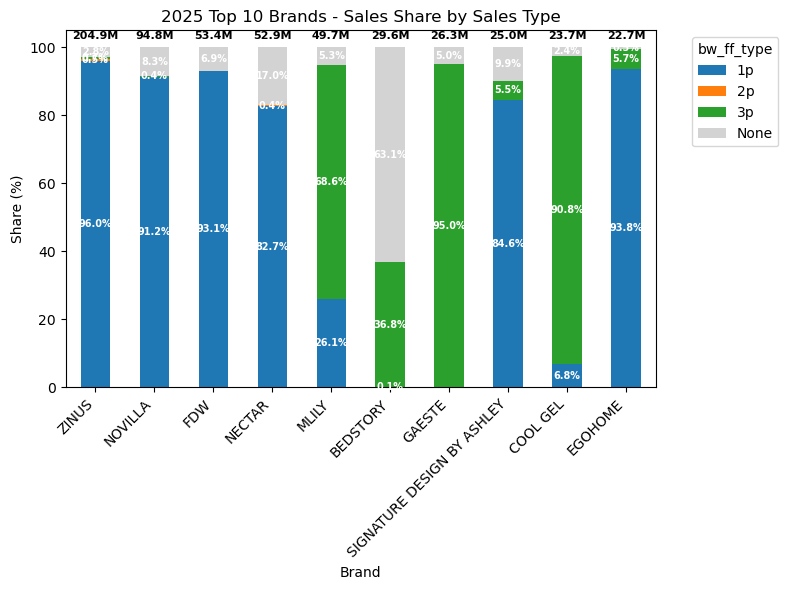

In [89]:
# 1. 매출 합계 기준 브랜드 정렬 (내림차순)
brand_total_sales = sales_pivot.sum(axis=1)               # 브랜드별 총 매출
brand_order = brand_total_sales.sort_values(ascending=False).index

# 2. sales_ratio도 동일한 순서로 재정렬
sales_ratio_sorted = sales_ratio.loc[brand_order]
brand_total_sales_sorted = brand_total_sales.loc[sales_ratio_sorted.index] / 1e6  # Million 단위 변환

# 3. 색상 매핑
colors = {
    '1p': '#1f77b4',
    '2p': '#ff7f0e',
    '3p': '#2ca02c',
    'None': 'lightgray'
}

# ===== 100% stacked bar chart =====
fig, ax = plt.subplots(figsize=(8, 6))

sales_ratio_sorted.plot(
    kind='bar',
    stacked=True,
    color=[colors[c] for c in sales_ratio_sorted.columns],
    ax=ax
)

# 각 segment에 비중(%) 표시
for idx, row in sales_ratio_sorted.iterrows():
    cumulative = 0
    for col in sales_ratio_sorted.columns:
        val = row[col]
        if val > 0:
            ax.text(
                x=list(sales_ratio_sorted.index).index(idx),
                y=cumulative + val/2,
                s=f"{val:.1f}%",
                ha='center', va='center',
                fontsize=7, color="white", weight="bold"
            )
        cumulative += val

# ===== 막대 상단에 총 매출(Million 단위) 표시 =====
for i, (brand, total_m) in enumerate(brand_total_sales_sorted.items()):
    ax.text(
        x=i,
        y=102,   # 100% stacked bar 위 (100보다 조금 위)
        s=f"{total_m:.1f}M",
        ha='center', va='bottom', fontsize=8, color="black", weight="bold"
    )

ax.set_ylabel("Share (%)")
ax.set_xlabel("Brand")
ax.set_title("2025 Top 10 Brands - Sales Share by Sales Type")
ax.legend(title="bw_ff_type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

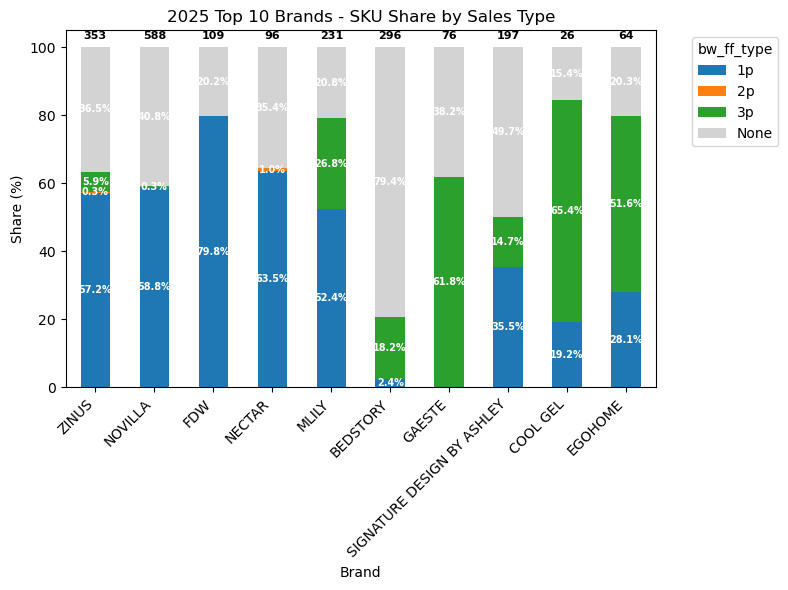

In [99]:
# 1. 매출 합계 기준 브랜드 정렬 (내림차순)
brand_order = sales_pivot.sum(axis=1).sort_values(ascending=False).index

# 2. sku_ratio, sku_pivot 동일 순서로 정렬
sku_ratio_sorted = sku_ratio.loc[brand_order]
sku_total_sorted = sku_pivot.sum(axis=1).loc[brand_order]

# 3. 색상 매핑
colors = {
    '1p': '#1f77b4',
    '2p': '#ff7f0e',
    '3p': '#2ca02c',
    'None': 'lightgray'
}

# ===== 100% stacked bar chart =====
fig, ax = plt.subplots(figsize=(8, 6))

sku_ratio_sorted.plot(
    kind='bar',
    stacked=True,
    color=[colors[c] for c in sku_ratio_sorted.columns],
    ax=ax
)

# 각 segment에 비중(%) 표시
for idx, row in sku_ratio_sorted.iterrows():
    cumulative = 0
    for col in sku_ratio_sorted.columns:
        val = row[col]
        if val > 0:
            ax.text(
                x=list(sku_ratio_sorted.index).index(idx),
                y=cumulative + val/2,
                s=f"{val:.1f}%",
                ha='center', va='center',
                fontsize=7, color="white", weight="bold"
            )
        cumulative += val

# 막대 상단에 유니크 SKU 개수 표시
for i, (brand, total_sku) in enumerate(sku_total_sorted.items()):
    ax.text(
        x=i,
        y=102,   # 100% stacked bar 위
        s=f"{int(total_sku):,}",   # 천 단위 구분기호 적용
        ha='center', va='bottom', fontsize=8, color="black", weight="bold"
    )

ax.set_ylabel("Share (%)")
ax.set_xlabel("Brand")
ax.set_title("2025 Top 10 Brands - SKU Share by Sales Type")
ax.legend(title="bw_ff_type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

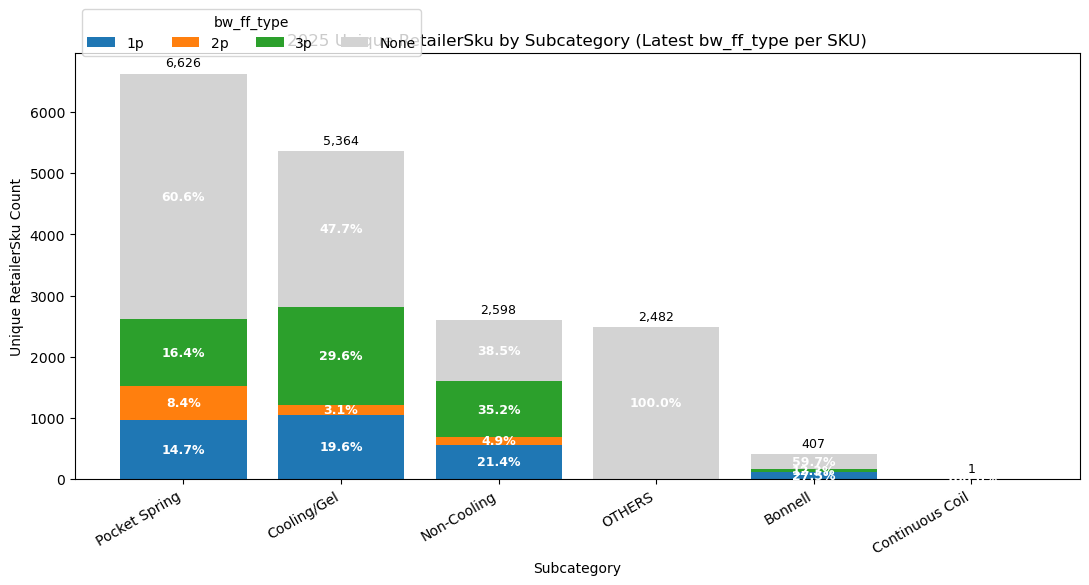

In [51]:
# ─────────────────────────────────────────────────────────
# (선택) 보기 좋게 subcategory를 총합 기준 내림차순 정렬
# ─────────────────────────────────────────────────────────
sku_pivot_sorted = sku_pivot.assign(_total=sku_pivot.sum(axis=1)) \
                            .sort_values('_total', ascending=False) \
                            .drop(columns=['_total'])
sku_ratio_sorted = sku_ratio.loc[sku_pivot_sorted.index]

# 색상 매핑 (None=회색)
colors = {'1p':'#1f77b4', '2p':'#ff7f0e', '3p':'#2ca02c', 'None':'lightgray'}
plot_cols = ['1p','2p','3p','None']  # 누적 순서

# ─────────────────────────────────────────────────────────
# 그래프 그리기 (누적 막대)
# ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

bottom = np.zeros(len(sku_pivot_sorted))
x = np.arange(len(sku_pivot_sorted))

for col in plot_cols:
    values = sku_pivot_sorted[col].values
    ax.bar(x, values, bottom=bottom, label=col, color=colors[col])
    bottom += values

# 제목/축/눈금
ax.set_title("2025 Unique RetailerSku by Subcategory (Latest bw_ff_type per SKU)")
ax.set_xlabel("Subcategory")
ax.set_ylabel("Unique RetailerSku Count")
ax.set_xticks(x)
ax.set_xticklabels(sku_pivot_sorted.index, rotation=30, ha='right')

# 범례
ax.legend(title="bw_ff_type", ncol=4, loc='upper left', bbox_to_anchor=(0, 1.12))

# ─────────────────────────────────────────────────────────
# 각 세그먼트에 비중(%) 라벨 표시 (3% 미만은 생략)
# ─────────────────────────────────────────────────────────
min_ratio_to_show = 3.0  # 필요 시 조정
for i, sub in enumerate(sku_pivot_sorted.index):
    y_base = 0
    for col in plot_cols:
        count = sku_pivot_sorted.loc[sub, col]
        if count <= 0:
            continue
        ratio = sku_ratio_sorted.loc[sub, col]
        if ratio >= min_ratio_to_show:
            ax.text(
                i,
                y_base + count/2,
                f"{ratio:.1f}%",
                ha='center', va='center',
                fontsize=9, color='white', weight='bold'
            )
        y_base += count

# (선택) 총합 라벨 막대 위에 표시
totals = sku_pivot_sorted.sum(axis=1)
for i, val in enumerate(totals):
    ax.text(i, val + max(totals)*0.01, f"{int(val):,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [49]:
# 1. 2024년 데이터만 필터링
df_2024 = df1[df1['year'] == 2024].copy()

# 2. bw_ff_type의 NaN → 'None' 변환
df_2024['bw_ff_type'] = df_2024['bw_ff_type'].fillna('None')

# 3. SKU별 최신 주차 데이터만 남기기
df_2024_sorted = df_2024.sort_values(['RetailerSku', 'WeekEnding'])
latest_2024 = df_2024_sorted.groupby('RetailerSku').tail(1)

# 4. category × bw_ff_type별 unique SKU 개수 집계
sku_counts = (
    latest_2024.groupby(['subcategory', 'bw_ff_type'])['RetailerSku']
               .nunique()
               .reset_index(name='sku_count')
)

# 5. Pivot 변환 (개수 테이블)
sku_pivot = (
    sku_counts.pivot(index='subcategory', columns='bw_ff_type', values='sku_count')
              .fillna(0)
)

# 6. 컬럼 순서 고정
desired_cols = ['1p','2p','3p','None']
for c in desired_cols:
    if c not in sku_pivot.columns:
        sku_pivot[c] = 0
sku_pivot = sku_pivot[desired_cols].astype(int)

# 7. 비중 계산
sku_ratio = sku_pivot.div(sku_pivot.sum(axis=1), axis=0) * 100

# 8. 출력
print("▶ 2024 category별 SKU 개수")
print(sku_pivot)

print("\n▶ 2024 category별 SKU 비중 (%)")
print(sku_ratio.round(1))

▶ 2024 category별 SKU 개수
bw_ff_type         1p   2p    3p  None
subcategory                           
Bonnell           112    2    50   243
Continuous Coil     0    0     0     1
Cooling/Gel      1053  164  1590  2557
Non-Cooling       557  127   915   999
OTHERS              0    0     0  2482
Pocket Spring     971  555  1085  4015

▶ 2024 category별 SKU 비중 (%)
bw_ff_type         1p   2p    3p   None
subcategory                            
Bonnell          27.5  0.5  12.3   59.7
Continuous Coil   0.0  0.0   0.0  100.0
Cooling/Gel      19.6  3.1  29.6   47.7
Non-Cooling      21.4  4.9  35.2   38.5
OTHERS            0.0  0.0   0.0  100.0
Pocket Spring    14.7  8.4  16.4   60.6
